# 04_interpretation: 研究結論與公衛情境解釋

## 1. 研究問題與假說
本研究探討美國高中生中，性別（`WhatIsYourSex`）與目前抽菸行為（`Smoking_Status`）是否存在顯著關聯。

* **虛無假說 ($H_0$):** $p_{\text{male}} = p_{\text{female}}$ (男女抽菸比例無顯著差異)
* **對立假說 ($H_a$):** $p_{\text{male}} \neq p_{\text{female}}$ (男女抽菸比例有顯著差異)
*顯著水準設定為 $\alpha = 0.05$*

In [1]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from IPython.display import display, Markdown

# 1. 讀取清理後的資料
df = pd.read_csv('../data/processed/yrbs_smoking_cleaned.csv')

# 2. 計算統計量
group_stats = df.groupby('WhatIsYourSex')['Smoking_Status'].agg(['sum', 'count'])
n_female, s_female = group_stats.loc[1.0, 'count'], group_stats.loc[1.0, 'sum']
n_male, s_male = group_stats.loc[2.0, 'count'], group_stats.loc[2.0, 'sum']

p_female, p_male = s_female / n_female, s_male / n_male
obs_diff = p_male - p_female

# 3. Z 檢定與信賴區間計算
z_stat, p_val = proportions_ztest([s_male, s_female], [n_male, n_female])
ci_low, ci_upp = confint_proportions_2indep(s_male, n_male, s_female, n_female, method='wald')

# 4. 動態輸出精簡版報告
report_text = f"""
## 2. 統計結果摘要
* **樣本數:** 女性 {n_female:,} 人，男性 {n_male:,} 人 (總計 {len(df):,} 筆有效樣本)
* **抽菸盛行率:** 女性 **{p_female:.2%}**，男性 **{p_male:.2%}** (男性高出 {obs_diff:.2%})
* **Z 檢定統計量:** `{z_stat:.4f}`
* **P 值 (P-value):** `{p_val:.4e}` 
* **95% 信賴區間:** `[{ci_low:.4f}, {ci_upp:.4f}]` (差異介於 {ci_low:.2%} 到 {ci_upp:.2%} 之間)
"""
display(Markdown(report_text))


## 2. 統計結果摘要
* **樣本數:** 女性 5,452 人，男性 5,240 人 (總計 10,692 筆有效樣本)
* **抽菸盛行率:** 女性 **17.35%**，男性 **21.68%** (男性高出 4.33%)
* **Z 檢定統計量:** `5.6496`
* **P 值 (P-value):** `1.6086e-08` 
* **95% 信賴區間:** `[0.0283, 0.0583]` (差異介於 2.83% 到 5.83% 之間)


## 3. 延伸問題

- **多重成癮物質分析:** 此問題想要確認當一個有吸菸習慣的受試者會不會更容易染上其他成癮物。


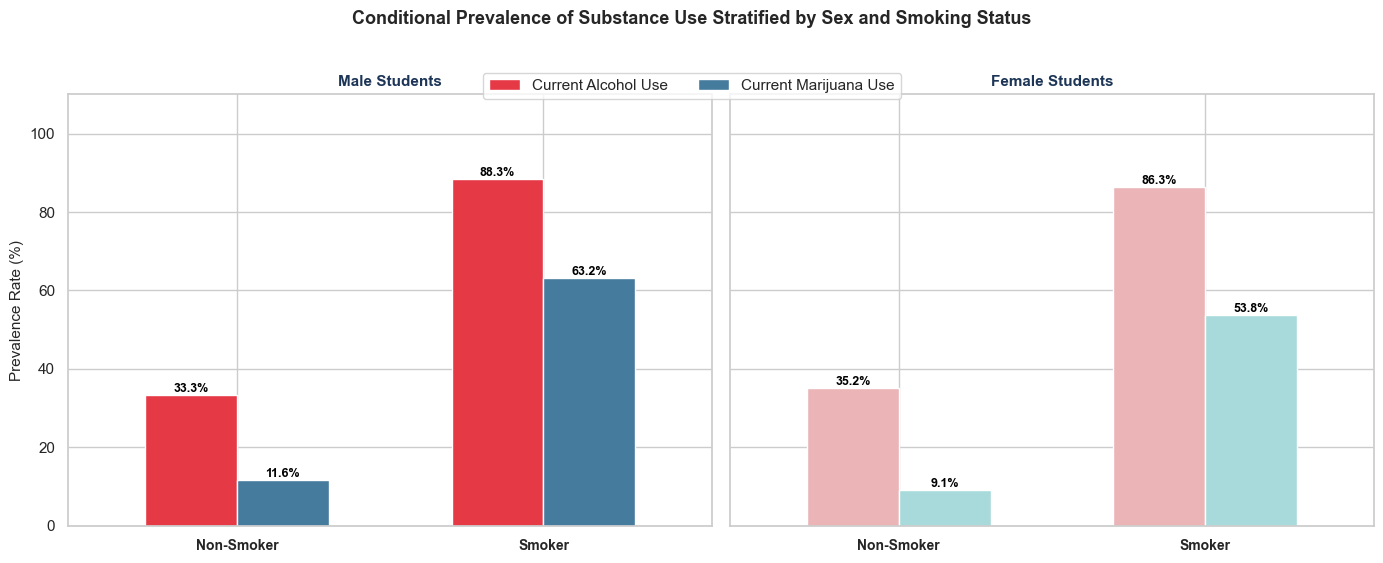

1. **檢定一：飲酒比例男女差異**
- 吸菸男生飲酒率: 88.3% | 吸菸女生飲酒率: 86.3%
- t 統計量: 1.4405
- p-value: 0.1499
- 結論：p >= 0.05，男女飲酒比例【沒有顯著差異】，看起來的微小差距只是隨機抽樣誤差。

2. **檢定二：大麻比例男女差異**
- 吸菸男生大麻率: 63.2% | 吸菸女生大麻率: 53.8%
- t 統計量: 4.5117
- p-value: 6.7816e-06
- 結論：p < 0.05，男女大麻比例存在【極顯著差異】男生抽菸後涉入大麻的比例顯著高於女生。

## 4. 結論與情境解釋

1. **統計決策 (Statistical Decision):** 由於 P 值 (< 0.001) 遠小於 0.05，且 95% 信賴區間未包含 0。因此我們有充分證據**拒絕虛無假說 ($H_0$)**。

2. **公衛情境解釋 (Interpretation in Context):** 數據顯示，男性高中生的抽菸比例顯著高於女性。我們有 95% 的信心認為，男性抽菸比例比女性高出約 3.06% 至 5.79%。
這項發現提示學校與公衛機構，在制定校園菸害防治政策時，應針對男性青少年設計更具針對性的衛教宣導與介入計畫，以有效降低整體校園吸菸率。
3. **延伸問題的總結** 在吸菸者中男女染上酒癮的比例是差不多的88.3%以及86.3%經檢定後確認是抽樣造成的微小誤差，但在大麻部分男性相較於女性更容易成癮63.2%以及53.8%經檢定後確認兩群體之間存在差異。且從長條圖可以明顯看出有吸菸者較無吸菸者更容易染上其他成癮物。所以如果有做任何防治政策時應考慮到使用其他成癮物的可能來做到更完善的防治。